Name:Branzen.B.V
Reg. No:212225100005
ElasticNet - Mean Squared Error: 0.63, R² Score: 0.49


C:\Users\acer\AppData\Local\Temp\ipykernel_21304\1136545676.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MSE', data=results_df, palette='viridis')
C:\Users\acer\AppData\Local\Temp\ipykernel_21304\1136545676.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R² Score', data=results_df, palette='viridis')


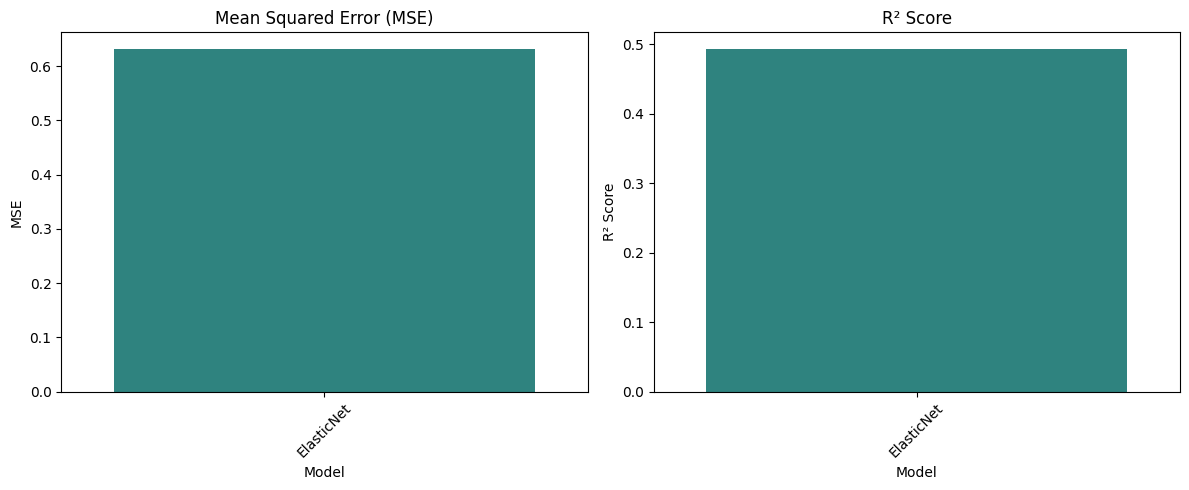

In [5]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
# Load the dataset
data = pd.read_csv("encoded_car_data (1).csv")
data.head()
# Data preprocessing
#data = data.drop(['CarName', 'car_ID'], axis=1)
data = pd.get_dummies(data, drop_first=True)
# Splitting the data into features and target variable
X = data.drop('price', axis=1)
y = data['price']
# Standardizing the features
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y.values.reshape(-1, 1))
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Define the models and pipelines
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5)
}
# Dictionary to store results
results = {}
# Train and evaluate each model
for name, model in models.items():
    # Create a pipeline with polynomial features and the model
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('regressor', model)
    ])
 # Fit the model
pipeline.fit(X_train, y_train)
# Make predictions
predictions = pipeline.predict(X_test)
 # Calculate performance metrics
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
 # Store results
results[name] = {'MSE': mse, 'R² Score': r2}
# Print results
print("Name:Branzen.B.V")
print("Reg. No:212225100005")
for model_name, metrics in results.items():
    print(f"{model_name} - Mean Squared Error: {metrics['MSE']:.2f}, R² Score: {metrics['R² Score']:.2f}")
# Visualization of the results
# Convert results to DataFrame for easier plotting
results_df = pd.DataFrame(results).T
results_df.reset_index(inplace=True)
results_df.rename(columns={'index': 'Model'}, inplace=True)
# Set the figure size
plt.figure(figsize=(12, 5))
# Bar plot for MSE
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='MSE', data=results_df, palette='viridis')
plt.title('Mean Squared Error (MSE)')
plt.ylabel('MSE')
plt.xticks(rotation=45)
# Bar plot for R² Score
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='R² Score', data=results_df, palette='viridis')
plt.title('R² Score')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
# Show the plots
plt.tight_layout()
plt.show()